# CoNLL Iterative Run Analysis Notebook — Fixed Scaled Injection Axes

This notebook analyses the completed `iter_conll` HPC run. The experiment trained on EWT as the source domain and incrementally injected CoNLL target examples across 20 iterations and 3 seeds (`42`, `123`, `456`).

The notebook focuses on **seed-averaged results** for final reporting, while still showing seed variability where useful.

Main files used:

```text
runs/iter_conll/summary.csv
runs/iter_conll/config.json
runs/iter_conll/seeds/seed_*/iter_*/metrics.json
runs/iter_conll/seeds/seed_*/iter_*/per_type_metrics.json
runs/iter_conll/seeds/seed_*/iter_*/confusion_matrix_*.csv
runs/iter_conll/seeds/seed_*/iter_*/train_log.jsonl
```

**Fixed scaled version:** target-injection plots use a transformed x-axis (`log10(n + 1)`) so `0` starts at the far left while the nonlinear injection schedule is still represented clearly.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 1. Paths and data loading

Run this notebook from the repository root. If needed, edit `RUN_DIR` manually.

In [2]:
RUN_DIR = Path("runs/iter_conll")

# Fallback only for testing this notebook outside the repo
if not RUN_DIR.exists() and Path("/mnt/data/summary.csv").exists():
    RUN_DIR = Path("/mnt/data")

SUMMARY_PATH = RUN_DIR / "summary.csv"
CONFIG_PATH = RUN_DIR / "config.json"

print("RUN_DIR:", RUN_DIR.resolve())
print("SUMMARY_PATH exists:", SUMMARY_PATH.exists())
print("CONFIG_PATH exists:", CONFIG_PATH.exists())

summary = pd.read_csv(SUMMARY_PATH)
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config_snapshot = json.load(f)
config = config_snapshot.get("config", config_snapshot)

summary.head()

RUN_DIR: C:\Users\rudra\OneDrive - ITU\Cross_domain_NER_Project_2026\runs\iter_conll
SUMMARY_PATH exists: True
CONFIG_PATH exists: True


,exp_name,seed,iteration,n_blocks,n_target_examples,n_source_examples,train_set_size,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_f1,token_acc,eval_loss,delta_f1_vs_iter0,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength,best_epoch,train_time_sec,peak_gpu_mem_mb
0,iter_conll,42,0,0,0,12543,12543,0.000000,ewt_dev,0.783188,0.769173,0.786032,0.775635,0.790890,0.868628,0.983021,0.100892,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.781699,NaN,NaN,0.638211,NaN,NaN,0.887608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,1015.741578,5586
1,iter_conll,42,0,0,0,12543,12543,0.000000,conll_test,0.753596,0.744027,0.742567,0.777754,0.730894,0.839912,0.959190,0.288673,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.750212,NaN,NaN,0.572668,NaN,NaN,0.909201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,1015.741578,5586
2,iter_conll,42,0,0,0,12543,12543,0.000000,astro_test,0.297822,0.044790,0.189711,0.461827,0.219775,0.086379,0.842049,2.157145,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.303104,0.0,0.0,0.551157,0.0,0.0,0.534243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097,170.0,2366.0,10436,61.0,1141.0,5940,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0,11,1015.741578,5586
3,iter_conll,42,1,5,150,12543,12693,0.011818,ewt_dev,0.785788,0.768942,0.786767,0.781762,0.789855,0.868609,0.982902,0.105517,0.002600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.788413,NaN,NaN,0.633406,NaN,NaN,0.885007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399,NaN,NaN,224,NaN,NaN,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,1081.352831,5592
4,iter_conll,42,1,5,150,12543,12693,0.011818,conll_test,0.821494,0.821815,0.820994,0.831882,0.811363,0.888736,0.970216,0.203766,0.067898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.811144,NaN,NaN,0.741834,NaN,NaN,0.912469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668,NaN,NaN,1661,NaN,NaN,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,1081.352831,5592


In [3]:
print("Summary shape:", summary.shape)
print("Seeds:", sorted(summary["seed"].unique()))
print("Iterations:", summary["iteration"].min(), "to", summary["iteration"].max())
print("Eval sets:", sorted(summary["eval_set"].unique()))
print("Expected rows =", summary["seed"].nunique() * summary["iteration"].nunique() * summary["eval_set"].nunique())
print("Schedule:", config.get("schedule", []))

Summary shape: (180, 83)
Seeds: [42, 123, 456]
Iterations: 0 to 19
Eval sets: ['astro_test', 'conll_test', 'ewt_dev']
Expected rows = 180
Schedule: [0, 150, 200, 250, 320, 410, 530, 680, 875, 1125, 1450, 1875, 2400, 3100, 4000, 5100, 6600, 8500, 10900, 14000]


## 2. Visual style template

All graphs use the requested warm editorial academic style.

In [4]:
BG = "#f6f1eb"          # warm beige/off-white
TEXT = "#2f241f"        # dark brown
EDGE = "#3d3128"        # dark brown-gray
GRID = "#8b6f5a"        # muted brown

DOMAIN_COLORS = {
    "ewt_dev": "#EFA6C1",      # muted pink
    "conll_test": "#8FD3B6",   # pastel mint green
    "astro_test": "#F4B183",   # soft peach / WIESP
}

DOMAIN_LABELS = {
    "ewt_dev": "EWT dev",
    "conll_test": "CoNLL test",
    "astro_test": "WIESP test",
}

METRIC_LABELS = {
    "entity_f1_micro": "Entity micro F1",
    "entity_f1_macro": "Entity macro F1",
    "entity_f1_weighted": "Entity weighted F1",
    "entity_precision": "Entity precision",
    "entity_recall": "Entity recall",
    "token_acc": "Token accuracy",
    "token_f1": "Token F1",
    "eval_loss": "Evaluation loss",
    "delta_f1_vs_iter0": "Δ micro F1 vs iter 0",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.titlesize": 17,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def style_ax(ax, grid_axis="y"):
    ax.set_facecolor(BG)
    ax.title.set_color(TEXT)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.tick_params(axis="both", colors=TEXT)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(EDGE)
    ax.spines["bottom"].set_color(EDGE)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    if grid_axis:
        ax.grid(True, axis=grid_axis, linestyle="--", linewidth=0.8, alpha=0.23, color=GRID)
    ax.set_axisbelow(True)
    return ax

def finish_plot(title, xlabel=None, ylabel=None, legend=True, rotate_x=False):
    ax = plt.gca()
    style_ax(ax)
    ax.set_title(title, color=TEXT, pad=20, loc="center")
    if xlabel:
        ax.set_xlabel(xlabel, color=TEXT, labelpad=10)
    if ylabel:
        ax.set_ylabel(ylabel, color=TEXT, labelpad=10)
    if rotate_x:
        plt.xticks(rotation=25, ha="right")
    if legend:
        leg = ax.legend(frameon=True, facecolor=BG, edgecolor=EDGE)
        if leg:
            for t in leg.get_texts():
                t.set_color(TEXT)
    plt.tight_layout()

def add_bar_labels(ax, bars, fmt="{:.3f}", y_offset=0.008):
    for bar in bars:
        h = bar.get_height()
        if np.isnan(h):
            continue
        ax.text(bar.get_x() + bar.get_width()/2, h + y_offset, fmt.format(h),
                ha="center", va="bottom", fontsize=9, color=TEXT)


def target_x(values):
    """
    Transform target-example counts for plotting.
    Uses log10(n + 1), so 0 stays at the far-left origin.
    """
    return np.log10(np.asarray(values, dtype=float) + 1.0)

def apply_target_xaxis(ax=None):
    """
    Apply readable original-count tick labels to transformed target-injection plots.
    """
    if ax is None:
        ax = plt.gca()

    schedule = config.get("config", {}).get("schedule", config.get("schedule", []))
    if schedule:
        tick_candidates = [0, 150, 410, 1125, 3100, 8500, 14000]
        ticks = [t for t in tick_candidates if t in schedule]
    else:
        ticks = [0, 150, 410, 1125, 3100, 8500, 14000]

    ax.set_xticks(target_x(ticks))
    ax.set_xticklabels([str(t) for t in ticks], rotation=0)
    ax.set_xlim(target_x([0])[0] - 0.03, target_x([max(ticks)])[0] + 0.03)
    return ax


## 3. Seed averaging setup

The final report uses the **average of the three seeds**, not a single run.

In [5]:
metric_cols = [
    "entity_f1_micro", "entity_f1_macro", "entity_f1_weighted",
    "entity_precision", "entity_recall",
    "token_acc", "token_f1", "eval_loss", "delta_f1_vs_iter0",
    "best_epoch", "train_time_sec", "peak_gpu_mem_mb",
]

f1_type_cols = [c for c in summary.columns if c.startswith("f1_")]
support_cols = [c for c in summary.columns if c.startswith("support_")]

avg = (
    summary
    .groupby(["iteration", "n_target_examples", "target_fraction", "eval_set"], as_index=False)
    [metric_cols + f1_type_cols + support_cols]
    .agg("mean")
)

std = (
    summary
    .groupby(["iteration", "n_target_examples", "target_fraction", "eval_set"], as_index=False)
    [metric_cols + f1_type_cols]
    .agg("std")
)

avg_conll = avg[avg["eval_set"] == "conll_test"].copy()
avg_ewt = avg[avg["eval_set"] == "ewt_dev"].copy()
avg_astro = avg[avg["eval_set"] == "astro_test"].copy()

final_iter = int(avg["iteration"].max())
final_avg = avg[avg["iteration"] == final_iter].copy()

avg.head()

,iteration,n_target_examples,target_fraction,eval_set,entity_f1_micro,entity_f1_macro,entity_f1_weighted,entity_precision,entity_recall,token_acc,token_f1,eval_loss,delta_f1_vs_iter0,best_epoch,train_time_sec,peak_gpu_mem_mb,f1_Archive,f1_CelestialObject,f1_CelestialObjectRegion,f1_CelestialRegion,f1_Citation,f1_Collaboration,f1_ComputingFacility,f1_Database,f1_Dataset,f1_EntityOfFutureInterest,f1_Event,f1_Fellowship,f1_Formula,f1_Grant,f1_Identifier,f1_Instrument,f1_LOC,f1_Mission,f1_Model,f1_ORG,f1_ObservationalTechniques,f1_Observatory,f1_PER,f1_Proposal,f1_Software,f1_Survey,f1_Tag,f1_Telescope,f1_TextGarbage,f1_URL,f1_Wavelength,support_Archive,support_CelestialObject,support_CelestialObjectRegion,support_CelestialRegion,support_Citation,support_Collaboration,support_ComputingFacility,support_Database,support_Dataset,support_EntityOfFutureInterest,support_Event,support_Fellowship,support_Formula,support_Grant,support_Identifier,support_Instrument,support_LOC,support_Mission,support_Model,support_ORG,support_ObservationalTechniques,support_Observatory,support_PER,support_Proposal,support_Software,support_Survey,support_Tag,support_Telescope,support_TextGarbage,support_URL,support_Wavelength
0,0,0,0.000000,astro_test,0.289347,0.044659,0.188723,0.471825,0.208901,0.839816,0.085508,2.374334,0.000000,13.333333,1148.632699,5584.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.306864,0.0,0.0,0.548685,0.0,0.0,0.528871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097.0,170.0,2366.0,10436.0,61.0,1141.0,5940.0,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0
1,0,0,0.000000,conll_test,0.748027,0.738499,0.736969,0.771486,0.726041,0.958408,0.835887,0.329222,0.000000,13.333333,1148.632699,5584.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.737612,NaN,NaN,0.567496,NaN,NaN,0.910389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0.000000,ewt_dev,0.781350,0.765107,0.784190,0.768206,0.795031,0.982345,0.860980,0.110274,0.000000,13.333333,1148.632699,5584.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.787790,NaN,NaN,0.620876,NaN,NaN,0.886656,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,399.0,NaN,NaN,224.0,NaN,NaN,343.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,150,0.011818,astro_test,0.273697,0.043237,0.182658,0.472713,0.192882,0.836746,0.084369,2.502046,-0.015650,13.666667,1185.349102,5593.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.306319,0.0,0.0,0.538485,0.0,0.0,0.495531,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,324.0,2419.0,484.0,148.0,6042.0,360.0,588.0,297.0,339.0,304.0,55.0,594.0,2401.0,5038.0,146.0,813.0,2097.0,170.0,2366.0,10436.0,61.0,1141.0,5940.0,159.0,1112.0,915.0,74.0,1881.0,192.0,350.0,3151.0
4,1,150,0.011818,conll_test,0.839450,0.839324,0.838504,0.852746,0.826594,0.972011,0.896858,0.186546,0.091423,13.666667,1185.349102,5593.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828847,NaN,NaN,0.759283,NaN,NaN,0.929842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1668.0,NaN,NaN,1661.0,NaN,NaN,1617.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Entity F1 across iterations

**Axis note:** plots using target examples on the x-axis are drawn at `log10(n + 1)` positions, but the tick labels show the original number of CoNLL examples. This keeps `0` at the far left and avoids visually pretending the nonlinear schedule is evenly spaced.

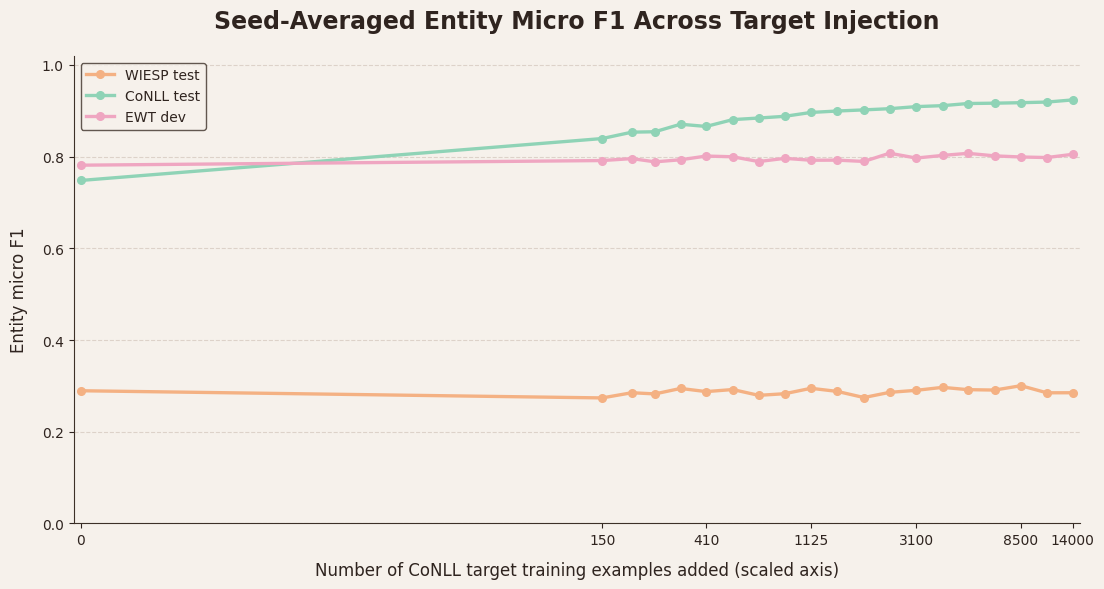

In [6]:
plt.figure(figsize=(11, 6))
for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(target_x(sub["n_target_examples"]), sub["entity_f1_micro"], marker="o", linewidth=2.4, markersize=5.5,
             color=DOMAIN_COLORS.get(eval_set, "gray"), label=DOMAIN_LABELS.get(eval_set, eval_set))
finish_plot("Seed-Averaged Entity Micro F1 Across Target Injection",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Entity micro F1")
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

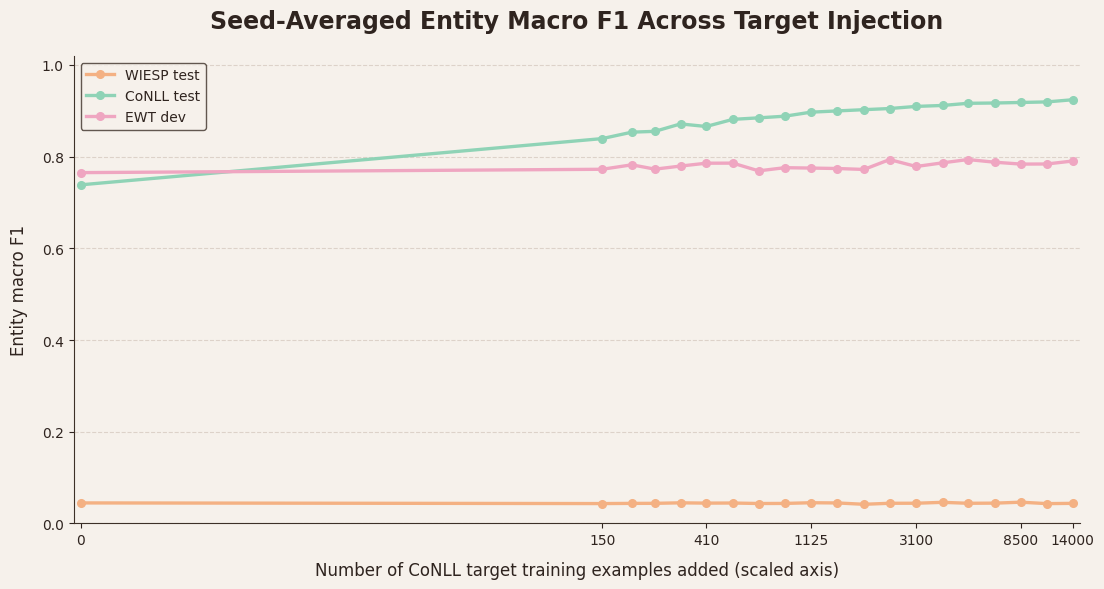

In [24]:
plt.figure(figsize=(11, 6))
for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(target_x(sub["n_target_examples"]), sub["entity_f1_macro"], marker="o", linewidth=2.4, markersize=5.5,
             color=DOMAIN_COLORS.get(eval_set, "gray"), label=DOMAIN_LABELS.get(eval_set, eval_set))
finish_plot("Seed-Averaged Entity Macro F1 Across Target Injection",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Entity macro F1")
plt.ylim(0, 1.02)
apply_target_xaxis()
plt.show()

## 5. CoNLL precision, recall, micro F1, macro F1, and token accuracy

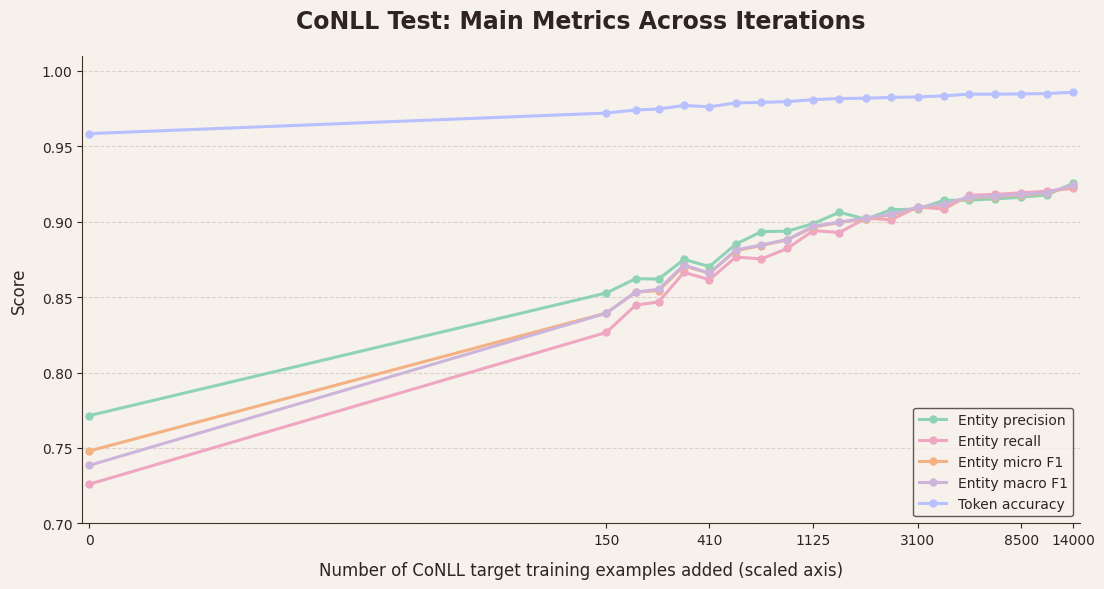

In [8]:
conll_metrics = ["entity_precision", "entity_recall", "entity_f1_micro", "entity_f1_macro", "token_acc"]
conll_colors = ["#8FD3B6", "#EFA6C1", "#F4B183", "#CDB4DB", "#B8C0FF"]

plt.figure(figsize=(11, 6))
for col, color in zip(conll_metrics, conll_colors):
    plt.plot(target_x(avg_conll["n_target_examples"]), avg_conll[col], marker="o", linewidth=2.2, markersize=5,
             color=color, label=METRIC_LABELS.get(col, col))
finish_plot("CoNLL Test: Main Metrics Across Iterations",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Score")
plt.ylim(0.70, 1.01)
apply_target_xaxis()
plt.show()

## 6. Seed variability around CoNLL micro F1

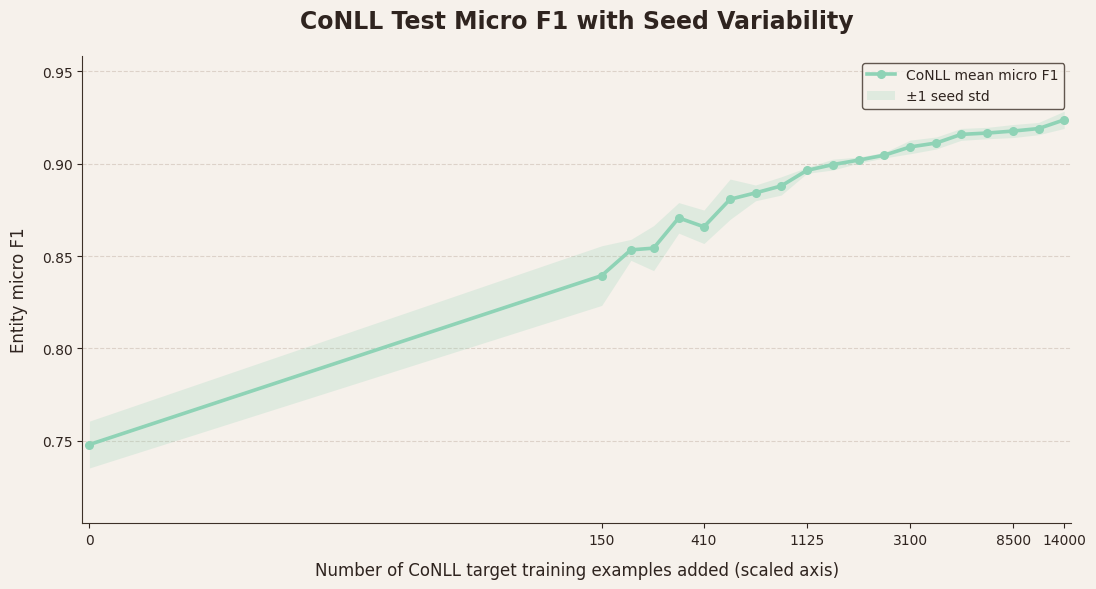

In [9]:
conll_std = std[std["eval_set"] == "conll_test"].sort_values("n_target_examples")
plot_df = avg_conll.sort_values("n_target_examples")
x = target_x(plot_df["n_target_examples"].to_numpy())
y = plot_df["entity_f1_micro"].to_numpy()
yerr = conll_std["entity_f1_micro"].to_numpy()

plt.figure(figsize=(11, 6))
plt.plot(x, y, marker="o", linewidth=2.6, markersize=5.5, color=DOMAIN_COLORS["conll_test"], label="CoNLL mean micro F1")
plt.fill_between(x, y - yerr, y + yerr, color=DOMAIN_COLORS["conll_test"], alpha=0.22, linewidth=0, label="±1 seed std")
finish_plot("CoNLL Test Micro F1 with Seed Variability",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Entity micro F1")
plt.ylim(max(0, (y - yerr).min() - 0.03), min(1.02, (y + yerr).max() + 0.03))
apply_target_xaxis()
plt.show()

## 7. Final iteration comparison across domains

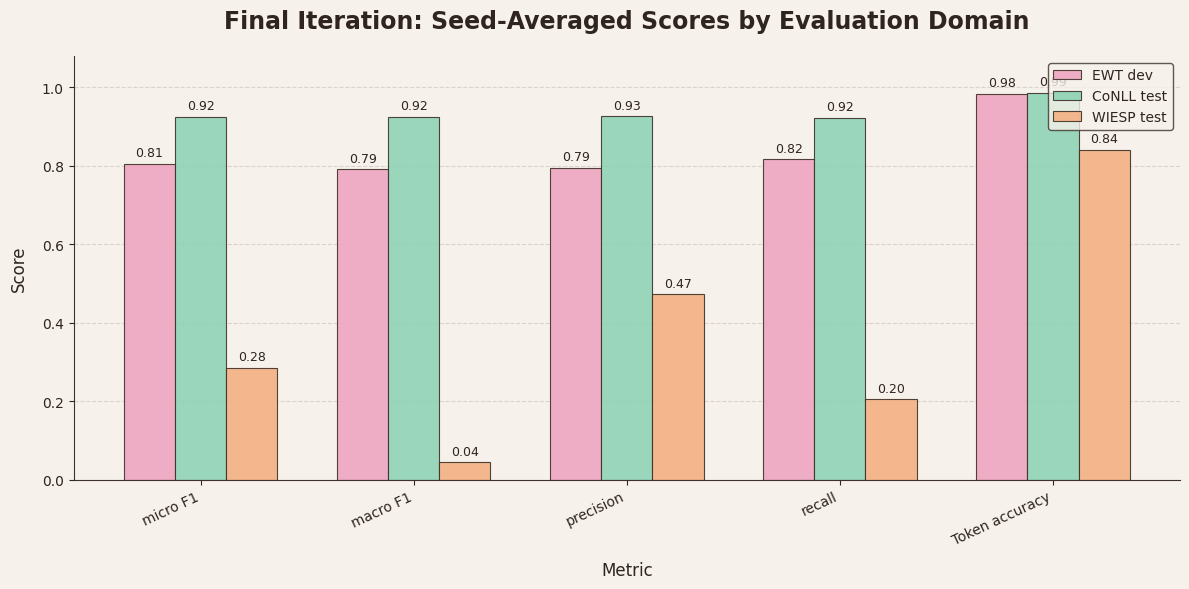

In [10]:
metrics_to_compare = ["entity_f1_micro", "entity_f1_macro", "entity_precision", "entity_recall", "token_acc"]
final_pivot = final_avg.set_index("eval_set")[metrics_to_compare].loc[["ewt_dev", "conll_test", "astro_test"]]

x = np.arange(len(metrics_to_compare))
width = 0.24
fig, ax = plt.subplots(figsize=(12, 6))
for i, eval_set in enumerate(final_pivot.index):
    values = final_pivot.loc[eval_set].values.astype(float)
    bars = ax.bar(x + (i - 1) * width, values, width=width, alpha=0.9,
                  color=DOMAIN_COLORS[eval_set], edgecolor=EDGE, linewidth=0.8,
                  label=DOMAIN_LABELS[eval_set])
    add_bar_labels(ax, bars, fmt="{:.2f}", y_offset=0.012)
ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m].replace("Entity ", "") for m in metrics_to_compare])
finish_plot("Final Iteration: Seed-Averaged Scores by Evaluation Domain",
            xlabel="Metric", ylabel="Score", rotate_x=True)
plt.ylim(0, 1.08)
plt.show()

## 8. Gain over iteration 0

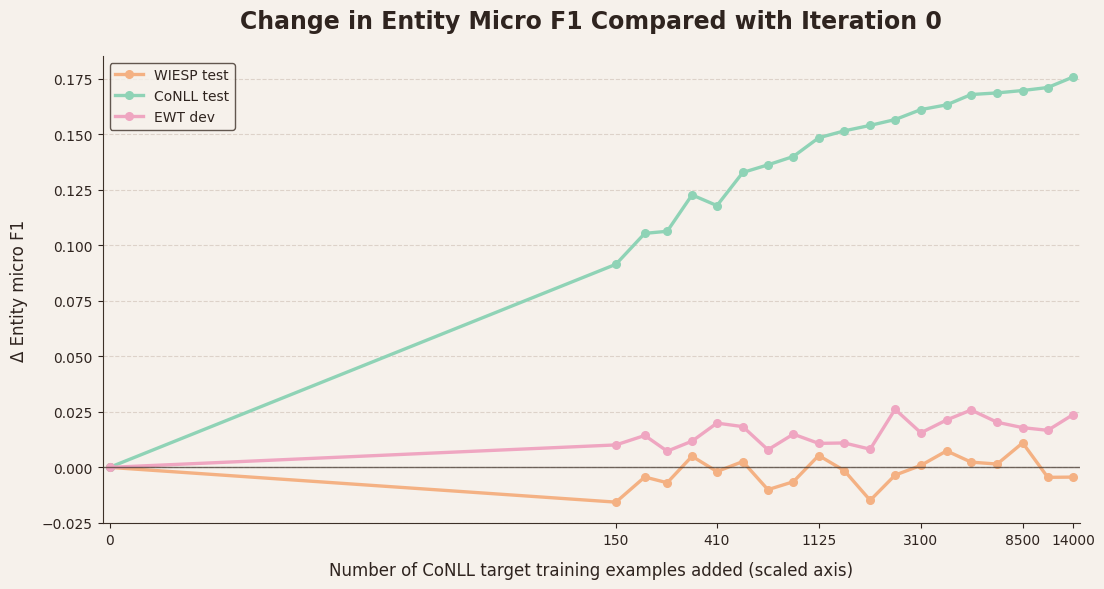

In [11]:
plt.figure(figsize=(11, 6))
for eval_set, sub in avg.groupby("eval_set"):
    sub = sub.sort_values("n_target_examples")
    plt.plot(target_x(sub["n_target_examples"]), sub["delta_f1_vs_iter0"], marker="o", linewidth=2.4, markersize=5.5,
             color=DOMAIN_COLORS.get(eval_set, "gray"), label=DOMAIN_LABELS.get(eval_set, eval_set))
plt.axhline(0, color=EDGE, linewidth=1.0, alpha=0.7)
finish_plot("Change in Entity Micro F1 Compared with Iteration 0",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Δ Entity micro F1")
apply_target_xaxis()
plt.show()

## 9. Per-entity CoNLL performance: LOC, ORG, PER

CoNLL `MISC` is not included because the project normalises `MISC` to `O`. Therefore, this focuses on `LOC`, `ORG`, and `PER`.

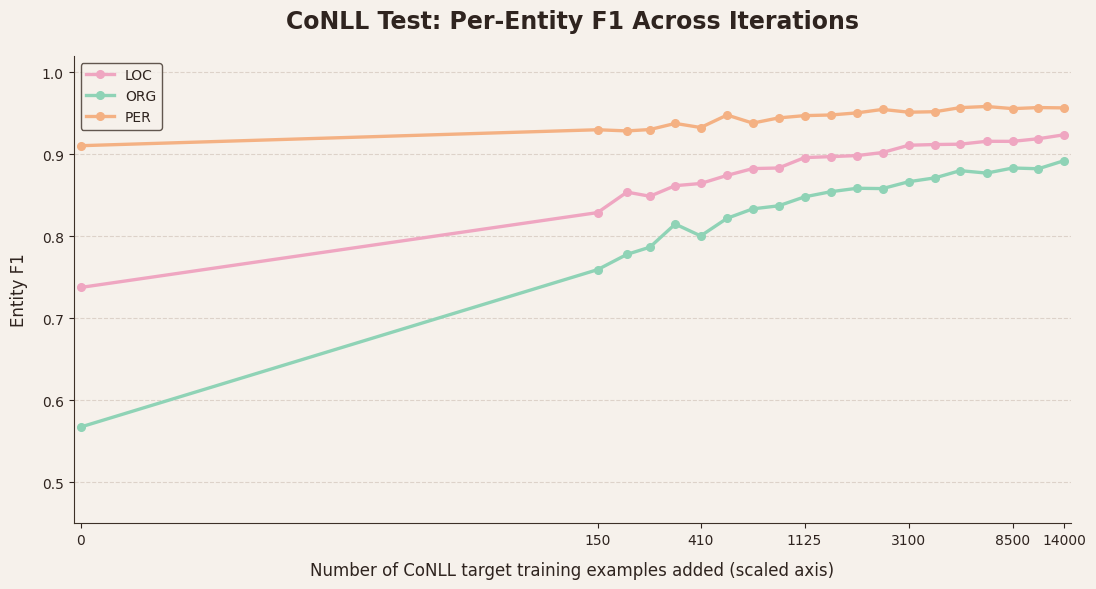

In [12]:
entity_cols = ["f1_LOC", "f1_ORG", "f1_PER"]
entity_colors = {"f1_LOC": "#EFA6C1", "f1_ORG": "#8FD3B6", "f1_PER": "#F4B183"}

plt.figure(figsize=(11, 6))
for col in entity_cols:
    plt.plot(target_x(avg_conll["n_target_examples"]), avg_conll[col], marker="o", linewidth=2.4, markersize=5.5,
             color=entity_colors[col], label=col.replace("f1_", ""))
finish_plot("CoNLL Test: Per-Entity F1 Across Iterations",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Entity F1")
plt.ylim(0.45, 1.02)
apply_target_xaxis()
plt.show()

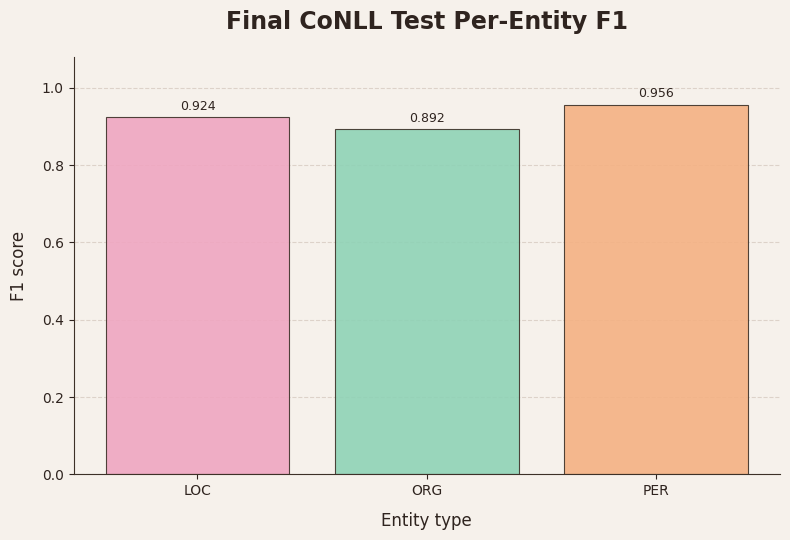

In [13]:
final_conll = avg_conll[avg_conll["iteration"] == final_iter].iloc[0]
entities = ["LOC", "ORG", "PER"]
values = [final_conll[f"f1_{e}"] for e in entities]
colors = ["#EFA6C1", "#8FD3B6", "#F4B183"]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(entities, values, color=colors, alpha=0.9, edgecolor=EDGE, linewidth=0.8)
add_bar_labels(ax, bars, fmt="{:.3f}", y_offset=0.012)
finish_plot("Final CoNLL Test Per-Entity F1", xlabel="Entity type", ylabel="F1 score", legend=False)
plt.ylim(0, 1.08)
plt.show()

## 10. Precision-recall balance on CoNLL

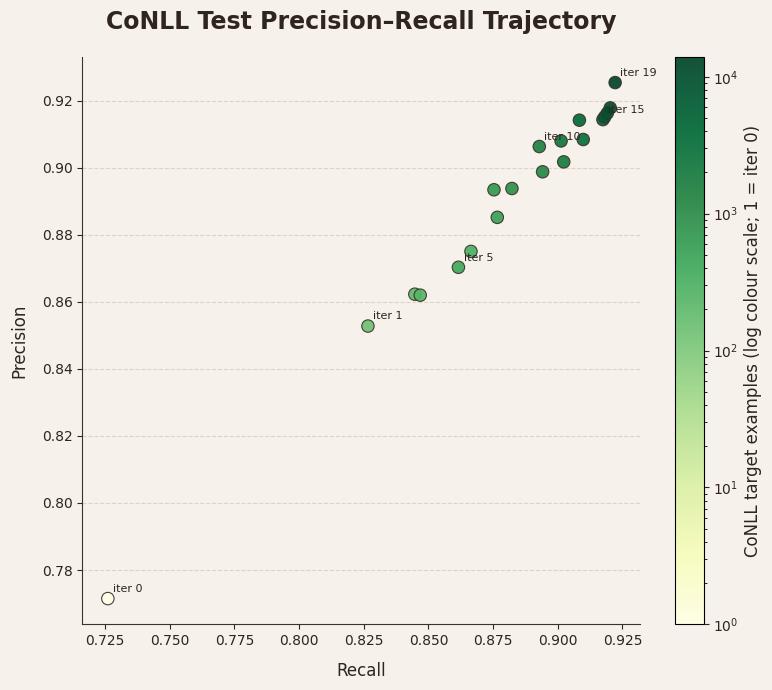

In [14]:
plt.figure(figsize=(8, 7))

# Colour represents target injection, so use log-normalisation while keeping iteration 0 visible as 1.
color_values = avg_conll["n_target_examples"].replace(0, 1)
sc = plt.scatter(avg_conll["entity_recall"], avg_conll["entity_precision"], s=80,
                 c=color_values, cmap="YlGn",
                 norm=mcolors.LogNorm(vmin=1, vmax=color_values.max()),
                 edgecolor=EDGE, linewidth=0.8, alpha=0.92)
for _, row in avg_conll.iterrows():
    if row["iteration"] in [0, 1, 5, 10, 15, 19]:
        plt.text(row["entity_recall"] + 0.002, row["entity_precision"] + 0.002,
                 f"iter {int(row['iteration'])}", fontsize=8, color=TEXT)
cbar = plt.colorbar(sc)
cbar.set_label("CoNLL target examples (log colour scale; 1 = iter 0)", color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.get_yticklabels(), color=TEXT)
finish_plot("CoNLL Test Precision–Recall Trajectory", xlabel="Recall", ylabel="Precision", legend=False)
plt.show()

## 11. Confusion matrices

This loads token-level confusion matrices from each seed and averages them. Default: final iteration CoNLL confusion matrix.

In [15]:
def load_confusion_matrices(run_dir, eval_set="conll_test", iteration=None):
    seed_root = run_dir / "seeds"
    if not seed_root.exists():
        print("No seeds folder found. Confusion matrices can only be loaded from the full run directory.")
        return []
    matrices = []
    pattern = f"confusion_matrix_{eval_set}.csv"
    for seed_dir in sorted(seed_root.glob("seed_*")):
        iter_dirs = sorted(seed_dir.glob("iter_*"))
        if iteration is not None:
            iter_dirs = [seed_dir / f"iter_{iteration:03d}"]
        for iter_dir in iter_dirs:
            path = iter_dir / pattern
            if path.exists():
                df = pd.read_csv(path, index_col=0)
                matrices.append((seed_dir.name, iter_dir.name, df))
    return matrices

def average_confusion_matrix(matrices):
    if not matrices:
        return None
    labels = sorted(set().union(*[set(m.index) | set(m.columns) for _, _, m in matrices]))
    aligned = []
    for _, _, m in matrices:
        aligned.append(m.reindex(index=labels, columns=labels, fill_value=0).astype(float))
    return sum(aligned) / len(aligned)

CONF_EVAL_SET = "conll_test"
CONF_ITERATION = final_iter
conf_mats = load_confusion_matrices(RUN_DIR, eval_set=CONF_EVAL_SET, iteration=CONF_ITERATION)
print(f"Loaded {len(conf_mats)} confusion matrices for {CONF_EVAL_SET} iteration {CONF_ITERATION}.")
avg_conf = average_confusion_matrix(conf_mats)
avg_conf

Loaded 3 confusion matrices for conll_test iteration 19.


,LOC,O,ORG,PER
gold\pred,,,,
LOC,1783.000000,65.333333,65.000000,11.666667
O,49.000000,39052.000000,109.666667,30.333333
ORG,82.000000,119.666667,2275.666667,18.666667
PER,14.333333,25.333333,47.000000,2686.333333


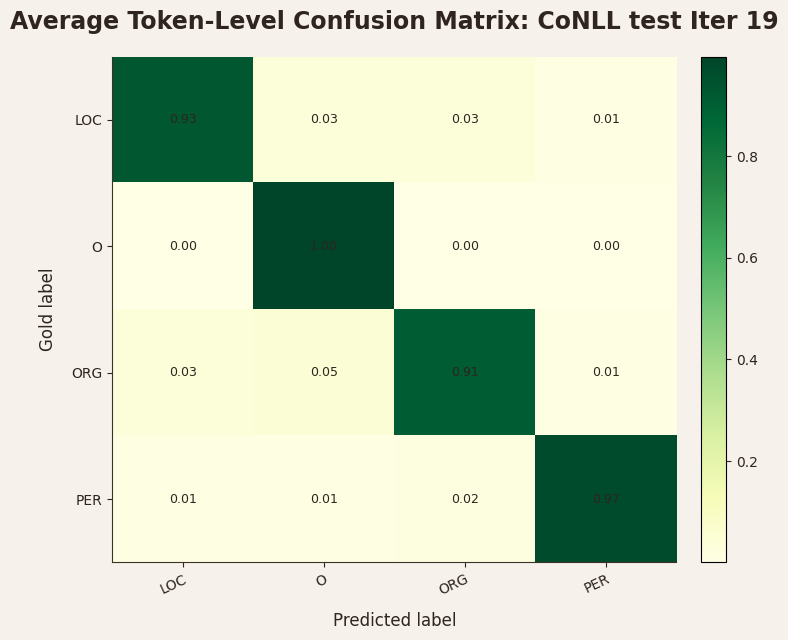

In [16]:
def plot_confusion_matrix(cm, title, normalize=True):
    if cm is None:
        print("No confusion matrix available to plot.")
        return
    plot_cm = cm.copy().astype(float)
    if normalize:
        row_sums = plot_cm.sum(axis=1).replace(0, np.nan)
        plot_cm = plot_cm.div(row_sums, axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow(plot_cm.values, cmap="YlGn", aspect="auto")
    ax.set_xticks(np.arange(len(plot_cm.columns)))
    ax.set_yticks(np.arange(len(plot_cm.index)))
    ax.set_xticklabels(plot_cm.columns)
    ax.set_yticklabels(plot_cm.index)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")

    for i in range(plot_cm.shape[0]):
        for j in range(plot_cm.shape[1]):
            val = plot_cm.iloc[i, j]
            text_val = f"{val:.2f}" if normalize else f"{val:.0f}"
            ax.text(j, i, text_val, ha="center", va="center", color=TEXT, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors=TEXT)
    style_ax(ax, grid_axis=None)
    ax.set_title(title, color=TEXT, pad=20, fontweight="bold")
    ax.set_xlabel("Predicted label", color=TEXT, labelpad=10)
    ax.set_ylabel("Gold label", color=TEXT, labelpad=10)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(avg_conf, title=f"Average Token-Level Confusion Matrix: {DOMAIN_LABELS.get(CONF_EVAL_SET, CONF_EVAL_SET)} Iter {CONF_ITERATION}", normalize=True)

## 12. Training dynamics from `train_log.jsonl`

In [17]:
def load_train_logs(run_dir):
    seed_root = run_dir / "seeds"
    rows = []
    if not seed_root.exists():
        print("No seeds folder found. Training logs can only be loaded from the full run directory.")
        return pd.DataFrame()
    for seed_dir in sorted(seed_root.glob("seed_*")):
        seed = int(seed_dir.name.replace("seed_", ""))
        for iter_dir in sorted(seed_dir.glob("iter_*")):
            iteration = int(iter_dir.name.replace("iter_", ""))
            log_path = iter_dir / "train_log.jsonl"
            if not log_path.exists():
                continue
            with open(log_path, "r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        record = json.loads(line)
                        record["seed"] = seed
                        record["iteration"] = iteration
                        rows.append(record)
    return pd.DataFrame(rows)

train_logs = load_train_logs(RUN_DIR)
print("Train logs shape:", train_logs.shape)
train_logs.head()

Train logs shape: (1227, 8)


,epoch,train_loss,dev_loss,dev_f1,lr,grad_norm,seed,iteration
0,1,2.324766,0.731230,0.000000,0.000002,8.623986,123,0
1,2,0.144422,0.264189,0.624451,0.000003,0.988067,123,0
2,3,0.060387,0.199157,0.728261,0.000005,1.054288,123,0
3,4,0.035757,0.200975,0.734137,0.000007,1.027903,123,0
4,5,0.024449,0.191179,0.747918,0.000008,0.956376,123,0


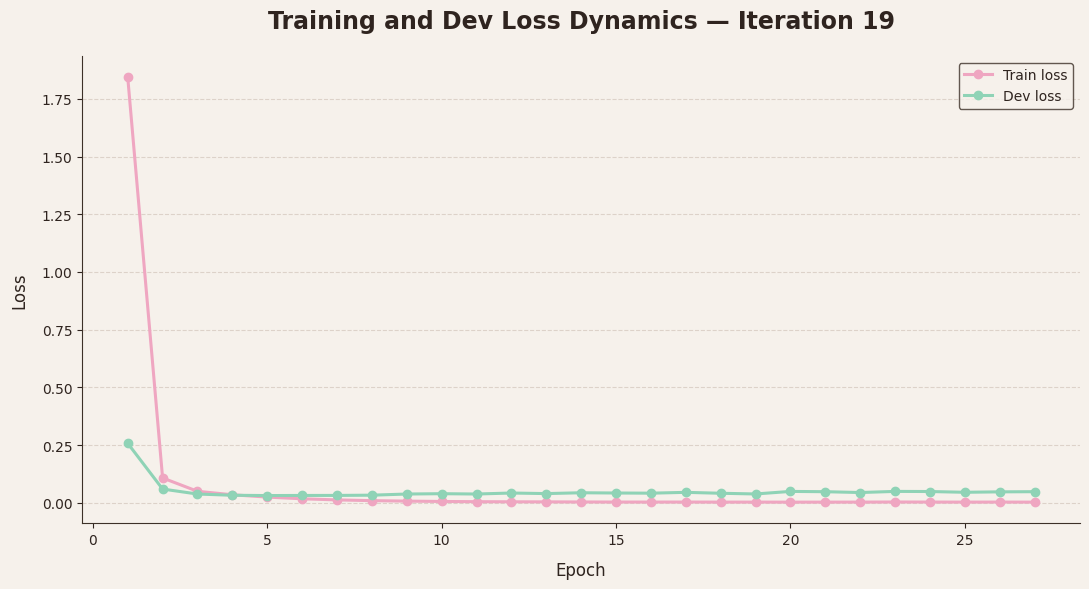

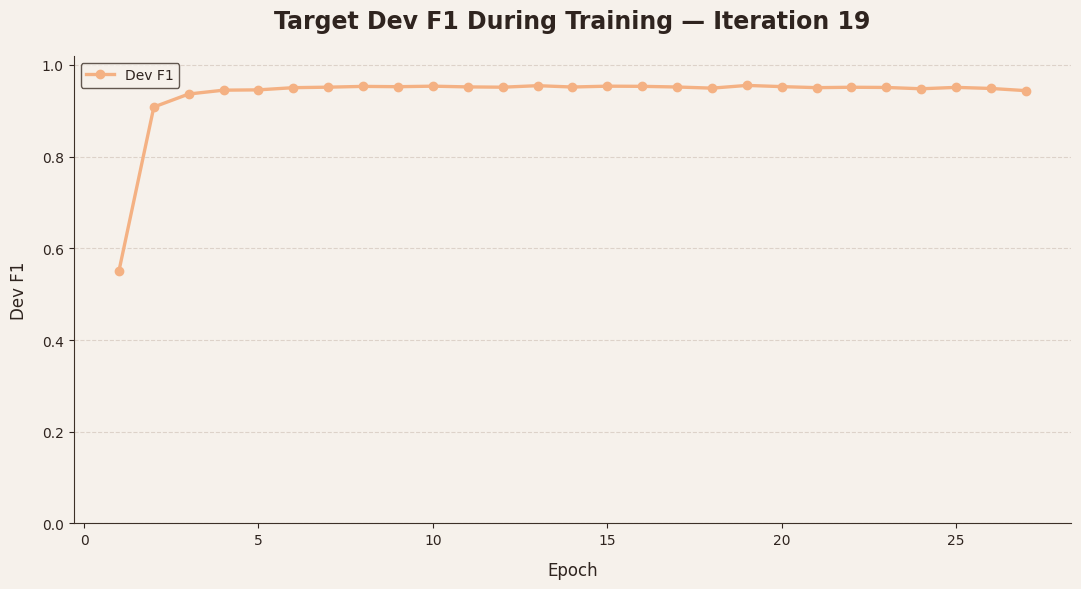

In [18]:
SELECTED_ITER_FOR_TRAINING = final_iter

if not train_logs.empty:
    tl = train_logs[train_logs["iteration"] == SELECTED_ITER_FOR_TRAINING]
    tl_avg = tl.groupby("epoch", as_index=False)[["train_loss", "dev_loss", "dev_f1"]].mean()

    plt.figure(figsize=(11, 6))
    plt.plot(tl_avg["epoch"], tl_avg["train_loss"], marker="o", linewidth=2.2, color="#EFA6C1", label="Train loss")
    plt.plot(tl_avg["epoch"], tl_avg["dev_loss"], marker="o", linewidth=2.2, color="#8FD3B6", label="Dev loss")
    finish_plot(f"Training and Dev Loss Dynamics — Iteration {SELECTED_ITER_FOR_TRAINING}", xlabel="Epoch", ylabel="Loss")
    plt.show()

    plt.figure(figsize=(11, 6))
    plt.plot(tl_avg["epoch"], tl_avg["dev_f1"], marker="o", linewidth=2.4, color="#F4B183", label="Dev F1")
    finish_plot(f"Target Dev F1 During Training — Iteration {SELECTED_ITER_FOR_TRAINING}", xlabel="Epoch", ylabel="Dev F1")
    plt.ylim(0, 1.02)
    plt.show()
else:
    print("No train logs loaded.")

## 13. Efficiency and resource analysis

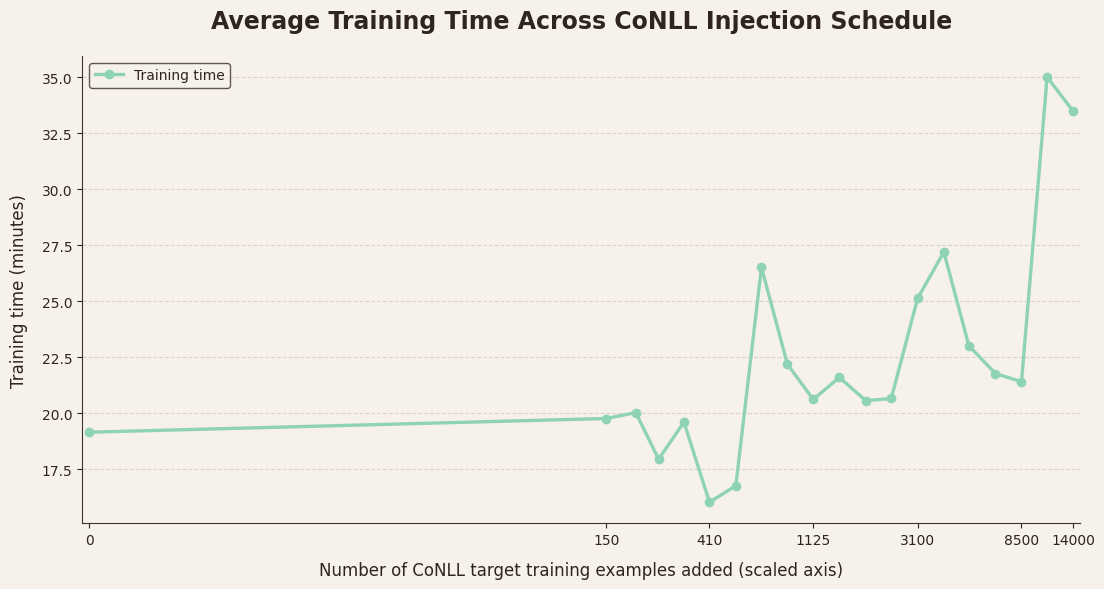

In [19]:
resource = summary[["seed", "iteration", "n_target_examples", "train_time_sec", "best_epoch", "peak_gpu_mem_mb"]].drop_duplicates()
resource_avg = resource.groupby(["iteration", "n_target_examples"], as_index=False).agg(
    train_time_sec_mean=("train_time_sec", "mean"),
    train_time_sec_std=("train_time_sec", "std"),
    best_epoch_mean=("best_epoch", "mean"),
    peak_gpu_mem_mb_mean=("peak_gpu_mem_mb", "mean"),
)

plt.figure(figsize=(11, 6))
plt.plot(target_x(resource_avg["n_target_examples"]), resource_avg["train_time_sec_mean"] / 60,
         marker="o", linewidth=2.4, color="#8FD3B6", label="Training time")
finish_plot("Average Training Time Across CoNLL Injection Schedule",
            xlabel="Number of CoNLL target training examples added (scaled axis)", ylabel="Training time (minutes)")
apply_target_xaxis()
plt.show()

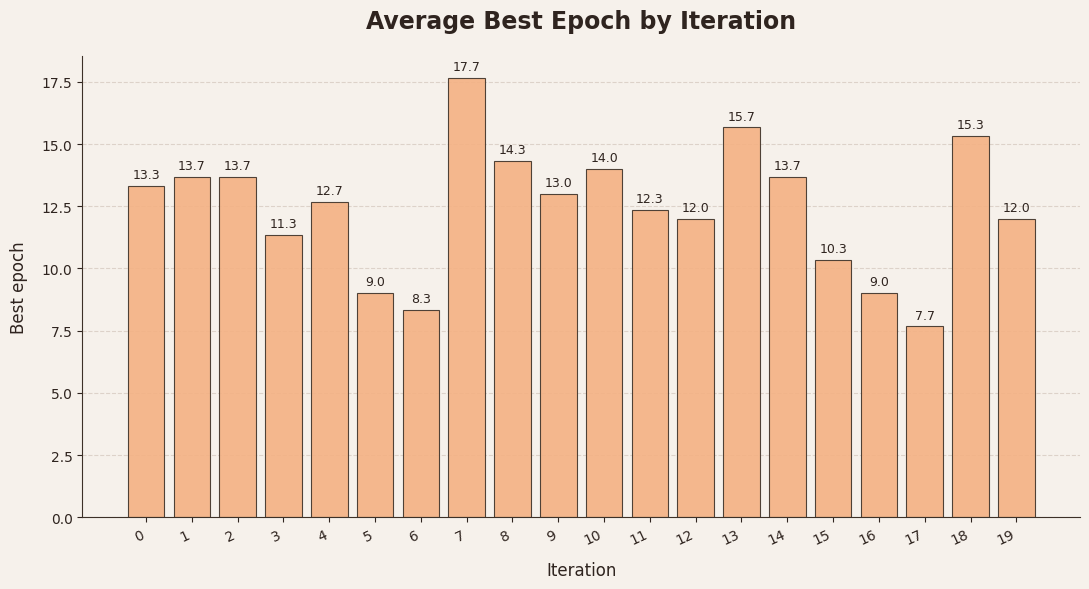

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(resource_avg["iteration"].astype(str), resource_avg["best_epoch_mean"],
              color="#F4B183", alpha=0.9, edgecolor=EDGE, linewidth=0.8)
add_bar_labels(ax, bars, fmt="{:.1f}", y_offset=0.2)
finish_plot("Average Best Epoch by Iteration", xlabel="Iteration", ylabel="Best epoch", legend=False, rotate_x=True)
plt.show()

## 14. Automatic result tables for the report

In [21]:
final_table = final_avg[[
    "eval_set", "n_target_examples", "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall", "token_acc", "token_f1", "eval_loss"
]].copy()
final_table["eval_set"] = final_table["eval_set"].map(DOMAIN_LABELS)
final_table.round(4)

,eval_set,n_target_examples,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,token_f1,eval_loss
57,WIESP test,14000,0.2850,0.0437,0.4724,0.2042,0.8396,0.0860,2.6900
58,CoNLL test,14000,0.9237,0.9241,0.9253,0.9222,0.9858,0.9513,0.0918
59,EWT dev,14000,0.8051,0.7905,0.7946,0.8161,0.9836,0.8768,0.0926


In [22]:
conll_progression = avg_conll[[
    "iteration", "n_target_examples", "target_fraction", "entity_f1_micro", "entity_f1_macro",
    "entity_precision", "entity_recall", "token_acc", "f1_LOC", "f1_ORG", "f1_PER"
]].round(4)
conll_progression

,iteration,n_target_examples,target_fraction,entity_f1_micro,entity_f1_macro,entity_precision,entity_recall,token_acc,f1_LOC,f1_ORG,f1_PER
1,0,0,0.0000,0.7480,0.7385,0.7715,0.7260,0.9584,0.7376,0.5675,0.9104
4,1,150,0.0118,0.8394,0.8393,0.8527,0.8266,0.9720,0.8288,0.7593,0.9298
7,2,200,0.0157,0.8534,0.8534,0.8622,0.8447,0.9741,0.8538,0.7779,0.9284
10,3,250,0.0195,0.8543,0.8552,0.8620,0.8468,0.9747,0.8488,0.7867,0.9301
13,4,320,0.0249,0.8707,0.8714,0.8750,0.8664,0.9770,0.8617,0.8149,0.9376
16,5,410,0.0317,0.8659,0.8658,0.8703,0.8616,0.9762,0.8643,0.8004,0.9325
19,6,530,0.0405,0.8808,0.8813,0.8852,0.8766,0.9788,0.8742,0.8219,0.9478
22,7,680,0.0514,0.8842,0.8846,0.8934,0.8753,0.9791,0.8825,0.8334,0.9379
25,8,875,0.0652,0.8880,0.8882,0.8938,0.8823,0.9796,0.8832,0.8371,0.9443
28,9,1125,0.0823,0.8964,0.8970,0.8987,0.8941,0.9809,0.8959,0.8480,0.9470
